In [42]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import List
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

def load_all_csvs(csv_paths: List[str]) -> pd.DataFrame:
        """Load and combine multiple experiment CSVs. Do simple data processing for later convenience"""
        dfs = []
        for path in csv_paths:
            df = pd.read_csv(path, index_col=0)
            df['source_file'] = Path(path).parent.name  # track which experiment it came from
            dfs.append(df)
        
        combined = pd.concat(dfs, ignore_index=True)
        
        # add in diff representations of red params for convenience
        combined[['resizeTrigger', 'sizeLimit']] = combined['reduce_triggerSz_sizeLim'].str.strip('()').str.split(',', expand=True).astype(int)
        combined['gap_size_range_tuple'] = combined['gap_size_range'].apply(ast.literal_eval)
        combined['reduce_triggerSz_sizeLim_tuple'] = combined['reduce_triggerSz_sizeLim'].apply(ast.literal_eval)
        
        combined['time_norm'] = combined['sumtest_time_mean'] / combined['sumtest_time_mean'].max()
        combined['coverage_norm'] = combined['result_coverage_mean'] / combined['result_coverage_mean'].max()
        combined['efficiency'] = combined['coverage_norm'] / combined['time_norm']
        return combined

In [43]:
paths =   ['data/results/751506081/ni_sweeping400/ni15_red500_250_sweep/results_sd751506081.csv', 'data/results/751506081/ni_sweeping400/ni15_red500_100_sweep/results_sd751506081.csv', 'data/results/751506081/ni_sweeping400/ni15_red500_10_sweep/results_sd751506081.csv', 'data/results/751506081/ni_sweeping400/ni15_red150_100_sweep/results_sd751506081.csv', 'data/results/751506081/ni_sweeping400/ni15_red150_10_sweep/results_sd751506081.csv', 'data/results/751506081/ni_sweeping400/ni15_red70_50_sweep/results_sd751506081.csv', 'data/results/751506081/ni_sweeping400/ni15_red70_10_sweep/results_sd751506081.csv', 'data/results/751506081/ni_sweeping400/ni15_red15_10_sweep/results_sd751506081.csv', 'data/results/751506081/ni_sweeping400/ni15_red10_5_sweep/results_sd751506081.csv', 'data/results/751506081/ni_sweeping400/ni15_red3_1_sweep/results_sd751506081.csv']
df = load_all_csvs(paths)
df


,master_seed,data_type,num_trials,dataset_size,uncertain_ratio,interval_size_range,mult_size_range,num_intervals,start_interval_range,gap_size,interval_width,num_intervals_range,gap_size_range,interval_width_range,reduce_triggerSz_sizeLim,independent_variable,distribution,min_time_mean,min_time_std,max_time_mean,max_time_std,sum_time_mean,sum_time_std,sumtest_time_mean,sumtest_time_std,sum_results,reduce_calls_mean,max_interval_count_mean,total_interval_count_mean,combine_calls_mean,result_size_mean,minEffectiveIntervalCountMean,convergedToTotSize,result_coverage_mean,source_file,resizeTrigger,sizeLimit,gap_size_range_tuple,reduce_triggerSz_sizeLim_tuple,time_norm,coverage_norm,efficiency
0,751506081,set,3,400,0.0,"(1, 100000)","(1, 5)",1,"(1, 1000)",NaN,NaN,NaN,"(2000, 2001)","(5, 6)","(500, 250)",num_intervals,DistributionType.UNIFORM,0.378000,0.022226,0.379000,0.023509,0.429333,0.203444,1.022333,1.056182,"[NumericRange(195727, 197728, '[)')]",0.0,1.0,400.0,400.0,1.0,1.0,2001.0,2001.0,ni15_red500_250_sweep,500,250,"(2000, 2001)","(500, 250)",0.009270,0.000178,0.019222
1,751506081,set,3,400,0.0,"(1, 100000)","(1, 5)",2,"(1, 1000)",NaN,NaN,NaN,"(2000, 2001)","(5, 6)","(500, 250)",num_intervals,DistributionType.UNIFORM,2.048667,0.013225,0.494667,0.003399,6.776667,0.139600,6.887000,0.387642,"[NumericRange(200503, 505259, '[)'), NumericRa...",246.0,996.0,190762.0,400.0,250.0,250.0,803005.0,803005.0,ni15_red500_250_sweep,500,250,"(2000, 2001)","(500, 250)",0.062445,0.071505,1.145086
2,751506081,set,3,400,0.0,"(1, 100000)","(1, 5)",3,"(1, 1000)",NaN,NaN,NaN,"(2000, 2001)","(5, 6)","(500, 250)",num_intervals,DistributionType.UNIFORM,4.269333,0.082560,0.716333,0.154836,13.009333,0.230769,13.202000,0.390710,"[NumericRange(197222, 1303978, '[)'), NumericR...",352.0,1485.0,280329.0,400.0,250.0,250.0,1605005.0,1605005.0,ni15_red500_250_sweep,500,250,"(2000, 2001)","(500, 250)",0.119704,0.142921,1.193951
3,751506081,set,3,400,0.0,"(1, 100000)","(1, 5)",4,"(1, 1000)",NaN,NaN,NaN,"(2000, 2001)","(5, 6)","(500, 250)",num_intervals,DistributionType.UNIFORM,5.171667,0.060643,0.729667,0.005312,16.759667,0.041652,16.703000,0.224839,"[NumericRange(200360, 2109116, '[)'), NumericR...",376.0,1984.0,377248.0,400.0,250.0,250.0,2407005.0,2407005.0,ni15_red500_250_sweep,500,250,"(2000, 2001)","(500, 250)",0.151448,0.214337,1.415247
4,751506081,set,3,400,0.0,"(1, 100000)","(1, 5)",6,"(1, 1000)",NaN,NaN,NaN,"(2000, 2001)","(5, 6)","(500, 250)",num_intervals,DistributionType.UNIFORM,7.697667,0.076321,0.961333,0.023697,28.654667,0.369143,28.022000,0.190139,"[NumericRange(195304, 3708060, '[)'), NumericR...",390.0,2916.0,573900.0,400.0,250.0,250.0,4011005.0,4011005.0,ni15_red500_250_sweep,500,250,"(2000, 2001)","(500, 250)",0.254079,0.357169,1.405736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,751506081,set,3,400,0.0,"(1, 100000)","(1, 5)",3,"(1, 1000)",NaN,NaN,NaN,"(2000, 2001)","(5, 6)","(3, 1)",num_intervals,DistributionType.UNIFORM,4.266000,0.077773,0.644000,0.019647,0.381333,0.013199,0.357667,0.002494,"[NumericRange(197222, 1803223, '[)')]",399.0,9.0,1206.0,400.0,1.0,1.0,1606001.0,1606001.0,ni15_red3_1_sweep,3,1,"(2000, 2001)","(3, 1)",0.003243,0.143010,44.097820
66,751506081,set,3,400,0.0,"(1, 100000)","(1, 5)",4,"(1, 1000)",NaN,NaN,NaN,"(2000, 2001)","(5, 6)","(3, 1)",num_intervals,DistributionType.UNIFORM,5.855000,0.122237,0.734000,0.008165,0.425000,0.014142,0.391667,0.007717,"[NumericRange(200360, 2608361, '[)')]",399.0,16.0,1612.0,400.0,1.0,1.0,2408001.0,2408001.0,ni15_red3_1_sweep,3,1,"(2000, 2001)","(3, 1)",0.003551,0.214426,60.379544
67,751506081,set,3,400,0.0,"(1, 100000)","(1, 5)",6,"(1, 1000)",NaN,NaN,NaN,"(2000, 2001)","(5, 6)","(3, 1)",num_intervals,DistributionType.UNIFORM,8.234333,0.088891,0.966333,0.016214,0.471667,0.007409,0.478333,0.038793,"[NumericRange(195304, 4207305, '[)')]",399.0,36.0,2430.0,400.0,1.0

In [22]:

# fig, axes=  plt.subplots(2, n, figsize=(6*n,12))

# for i, ni in enumerate(sorted(df['num_intervals'].unique())):
#     df_ni = df[df['num_intervals'] == ni].copy()

#     # PLot 1: time
#     ax = axes[0, i]
#     y = df_ni['time_rel']
#     ax.plot(x_labels, y, marker='o')
#     ax.set_title(f'ni={ni}')
#     ax.set_xlabel('red')
#     ax.tick_params(axis='x', rotation=45)
#     ax.grid(True)


# # for i, red_tuple in enumerate(sorted(df['reduce_triggerSz_sizeLim_tuple'].unique())):
# #     df_ni = df[df['reduce_triggerSz_sizeLim_tuple'] == red_tuple].copy()

# #     # PLot 1: time
# #     ax = axes[1, i]
# #     y = df_ni['sum_time_mean']
# #     ax.plot(x_labels, y, marker='o')
# #     ax.set_title(f'ni={ni}')
# #     ax.set_xlabel('red')
# #     ax.tick_params(axis='x', rotation=45)
# #     ax.grid(True)

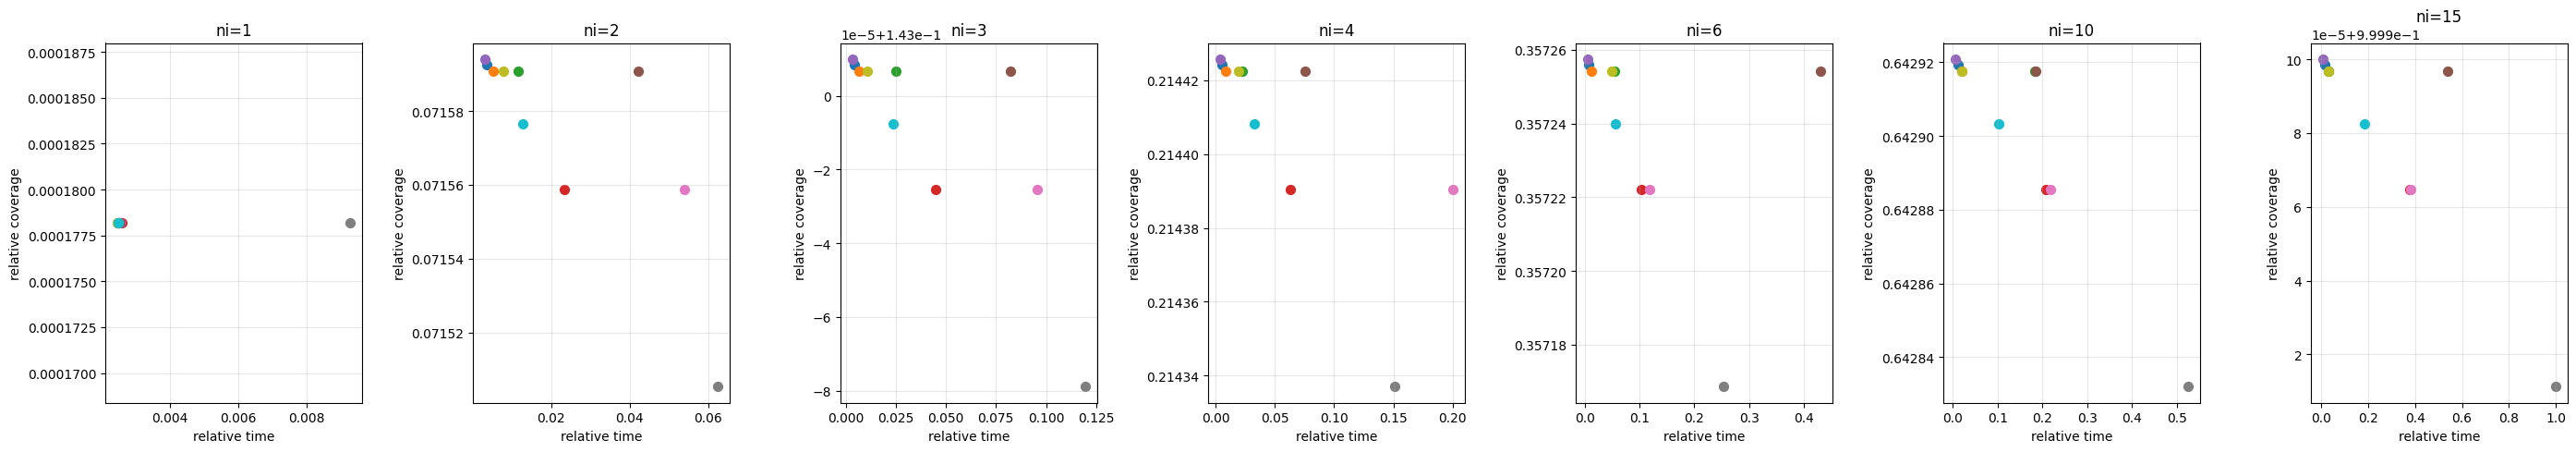

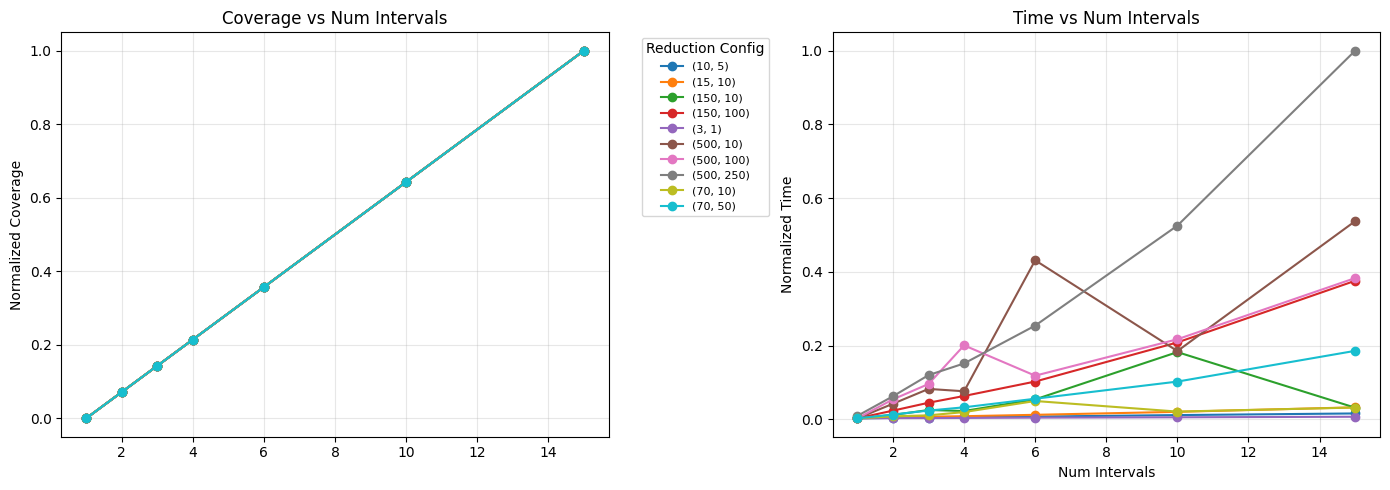

In [40]:
ni_values = sorted(df['num_intervals'].unique())
red_configs = sorted(df['reduce_triggerSz_sizeLim'].unique())

# pareto plots: time vs coverage for each ni and red_param
n_cols = len(ni_values)
fig, axes = plt.subplots(1, n_cols, figsize=(4*n_cols, 5))
axes = axes.flatten() if len(ni_values) > 1 else [axes]

# create scatter plot with each red param for each ni
for i, ni in enumerate(ni_values):
    ax = axes[i]
    ni_df = df[df['num_intervals'] == ni]
    for r in red_configs:
        sub = ni_df[ni_df['reduce_triggerSz_sizeLim'] == r]
        ax.scatter(sub['time_norm'], sub['coverage_norm'], label=str(r), s=50)
    ax.set_title(f'ni={ni}')
    ax.set_xlabel('relative time')
    ax.set_ylabel('relative coverage')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ========== 2. Normalized line plots ==========
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for r in red_configs:
    sub = df[df['reduce_triggerSz_sizeLim'] == r].sort_values('num_intervals')
    axes[0].plot(sub['num_intervals'], sub['coverage_norm'], marker='o', label=str(r))
    axes[1].plot(sub['num_intervals'], sub['time_norm'], marker='o', label=str(r))

axes[0].set_ylabel('Normalized Coverage')
axes[0].set_title('Coverage vs Num Intervals')
axes[0].grid(True, alpha=0.3)

axes[1].set_ylabel('Normalized Time')
axes[1].set_xlabel('Num Intervals')
axes[1].set_title('Time vs Num Intervals')
axes[1].grid(True, alpha=0.3)

axes[0].legend(title='Reduction Config', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

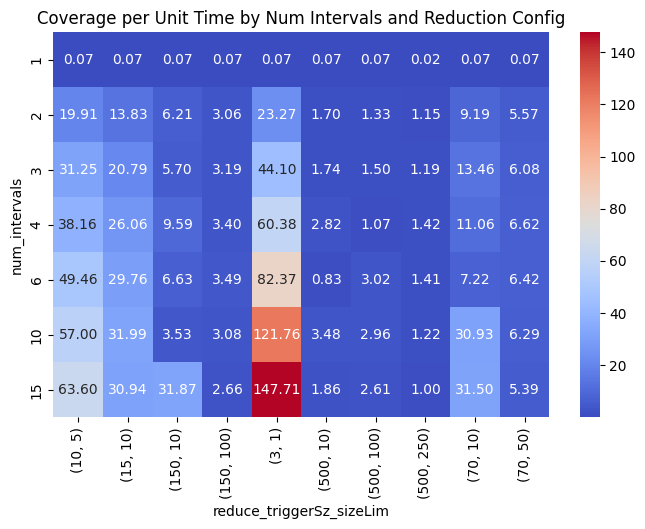

In [44]:
pivot_eff = df.pivot_table(
    index='num_intervals',
    columns='reduce_triggerSz_sizeLim',
    values='efficiency',
    aggfunc='mean'
)

plt.figure(figsize=(8,5))
sns.heatmap(pivot_eff, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Coverage per Unit Time by Num Intervals and Reduction Config")
plt.show()

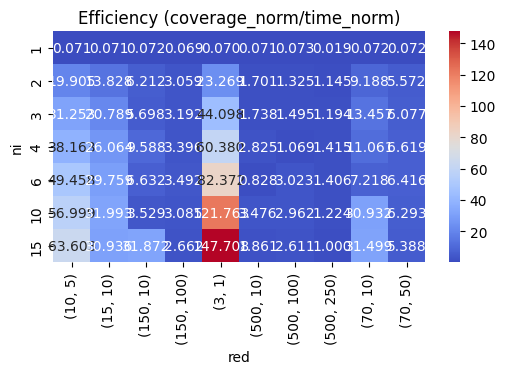

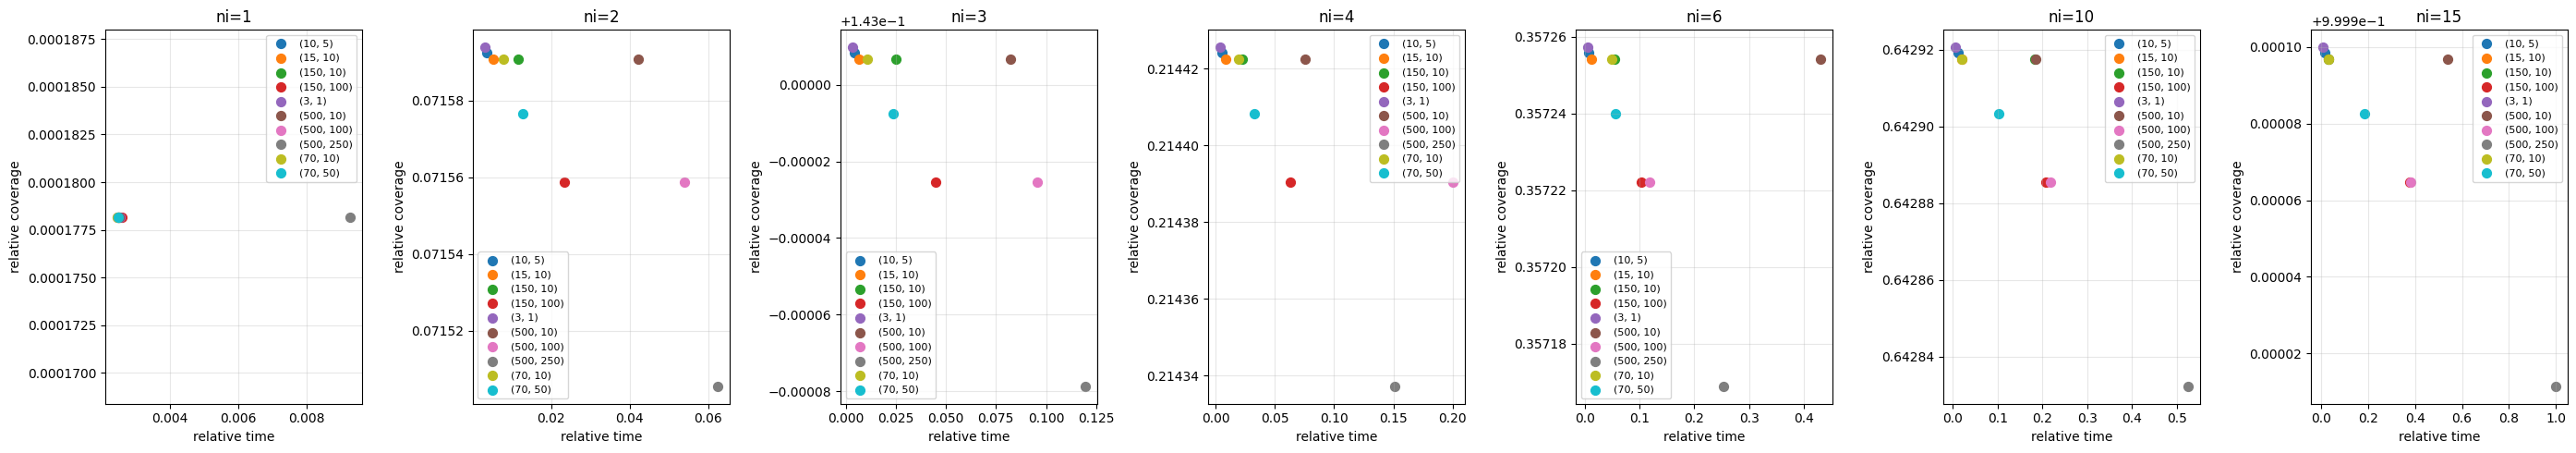

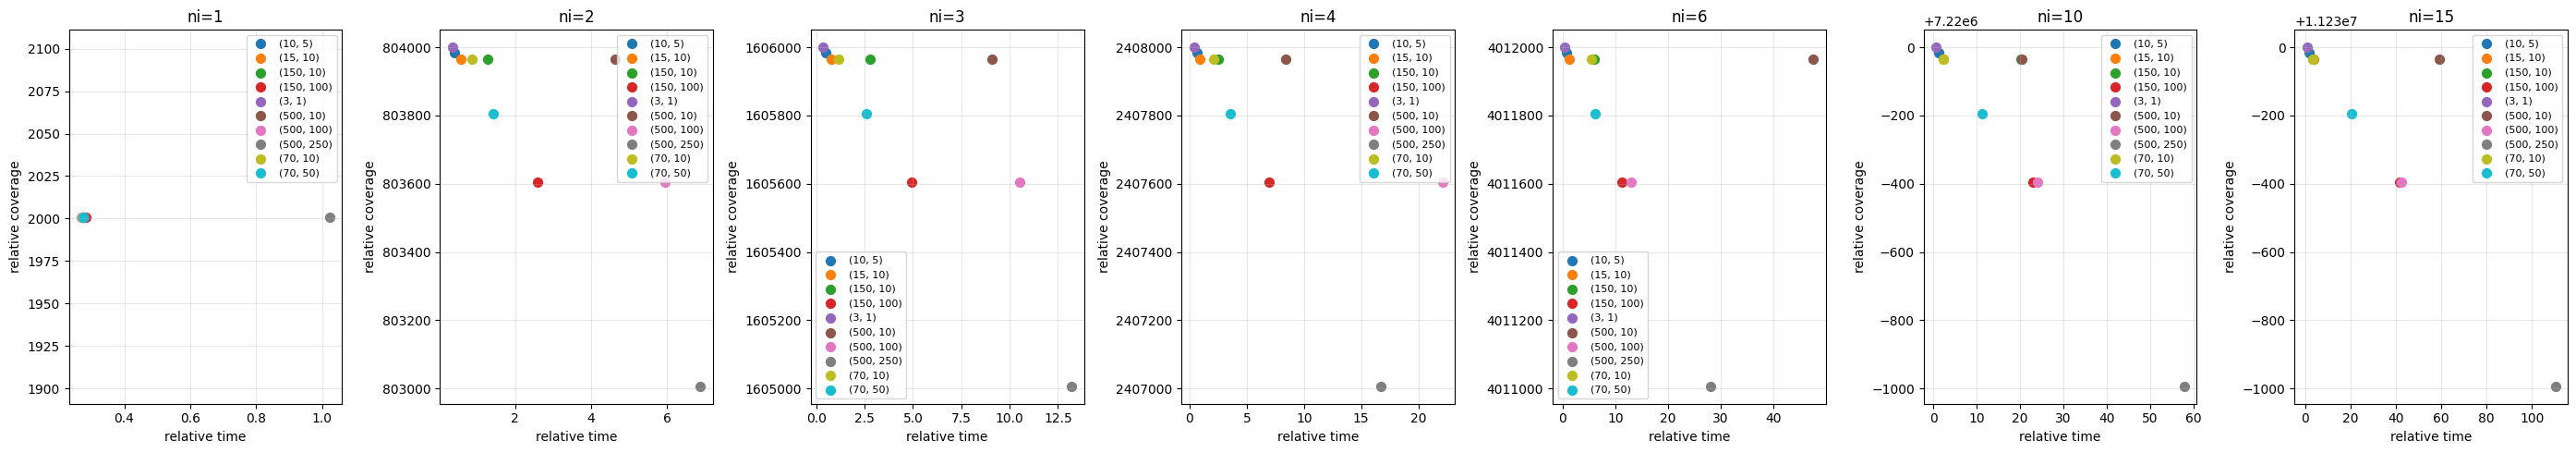

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# heatmap showing efficiency
df['efficiency'] = df['coverage_norm'] / df['time_norm']
pivot_eff = df.pivot_table(
    index='num_intervals',
    columns='reduce_triggerSz_sizeLim',
    values='efficiency',
    aggfunc='mean'
)

plt.figure(figsize=(6,3))
sns.heatmap(pivot_eff, annot=True, fmt=".3f", cmap="coolwarm")
plt.title("Efficiency (coverage_norm/time_norm)")
plt.xlabel("red")
plt.ylabel("ni")
plt.show()


# raw coverage vs time scatter plots
ni_values = sorted(df['num_intervals'].unique())
red_configs = sorted(df['reduce_triggerSz_sizeLim'].unique())

fig, axes = plt.subplots(1, len(ni_values), figsize=(4*len(ni_values),5))
axes = axes.flatten() if len(ni_values) > 1 else [axes]

for i, ni in enumerate(ni_values):
    ax = axes[i]
    # avoid scientific notation
    ax.ticklabel_format(style='plain', axis='y')
    ax.ticklabel_format(style='plain', axis='x')
    
    ni_df = df[df['num_intervals'] == ni]
    for r in red_configs:
        sub = ni_df[ni_df['reduce_triggerSz_sizeLim'] == r]
        ax.scatter(sub['time_norm'], sub['coverage_norm'], label=str(r), s=50)
        # ax.text(sub['time_norm'].iloc[0], sub['coverage_norm'].iloc[0], f"({sub['sumtest_time_mean'].iloc[0]:.2f}, )", ha="center", va="bottom")
    ax.set_title(f'ni={ni}')
    ax.set_xlabel('relative time')
    ax.set_ylabel('relative coverage')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, len(ni_values), figsize=(4*len(ni_values),5))
axes = axes.flatten() if len(ni_values) > 1 else [axes]

for i, ni in enumerate(ni_values):
    ax = axes[i]
    # avoid scientific notation
    ax.ticklabel_format(style='plain', axis='y')
    ax.ticklabel_format(style='plain', axis='x')
    
    ni_df = df[df['num_intervals'] == ni]
    for r in red_configs:
        sub = ni_df[ni_df['reduce_triggerSz_sizeLim'] == r]
        ax.scatter(sub['sumtest_time_mean'], sub['result_coverage_mean'], label=str(r), s=50)
        # ax.text(sub['time_norm'].iloc[0], sub['coverage_norm'].iloc[0], f"({sub['sumtest_time_mean'].iloc[0]:.2f}, )", ha="center", va="bottom")
    ax.set_title(f'ni={ni}')
    ax.set_xlabel('relative time')
    ax.set_ylabel('relative coverage')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [57]:
def plot_temp(df):
    # heatmap summary
    df['inefficiency'] = df['coverage_norm'] / df['time_norm']
    pivot_eff = df.pivot_table(
        index='num_intervals',
        columns='reduce_triggerSz_sizeLim',
        values='inefficiency',
        aggfunc='mean'
    )
    
    plt.figure(figsize=(6,3))
    sns.heatmap(pivot_eff, annot=True, fmt=".3f", cmap="coolwarm", annot_kws={"size": 6})
    plt.title("inefficiency (coverage_norm/time_norm)")
    plt.xlabel("red")
    plt.ylabel("ni")
    plt.show()
    
    # normalized scatter 
    ni_values = sorted(df['num_intervals'].unique())
    red_configs = sorted(df['reduce_triggerSz_sizeLim'].unique())
    
    fig, axes = plt.subplots(1, len(ni_values), figsize=(4*len(ni_values),3))
    axes = axes.flatten() if len(ni_values) > 1 else [axes]
    for i, ni in enumerate(ni_values):
        ax = axes[i]
        ni_df = df[df['num_intervals'] == ni]
        for r in red_configs:
            sub = ni_df[ni_df['reduce_triggerSz_sizeLim'] == r]
            ax.scatter(sub['time_norm'], sub['coverage_norm'], label=str(r), s=50)
    
        # no sci notation
        ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=False, useOffset=False))
        ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=False, useOffset=False))
        
        ax.set_title(f'ni={ni}')
        ax.set_xlabel('relative time')
        ax.set_ylabel('relative coverage')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    
    # # scatter raw
    # fig, axes = plt.subplots(1, len(ni_values), figsize=(4*len(ni_values),5))
    # axes = axes.flatten() if len(ni_values) > 1 else [axes]
    
    # for i, ni in enumerate(ni_values):
    #     ax = axes[i]
        
    #     ni_df = df[df['num_intervals'] == ni]
    #     for r in red_configs:
    #         sub = ni_df[ni_df['reduce_triggerSz_sizeLim'] == r]
    #         ax.scatter(sub['sumtest_time_mean'], sub['result_coverage_mean'], label=str(r), s=50)

    #     # remove sci notation
    #     ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=False, useOffset=False))
    #     ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=False, useOffset=False))
        
    #     ax.set_title(f'ni={ni}')
    #     ax.set_xlabel('time (raw)')
    #     ax.set_ylabel('coverage (raw)')
    #     ax.grid(True, alpha=0.3)
    #     ax.legend(fontsize=8)
    
    # plt.tight_layout()
    # plt.show()

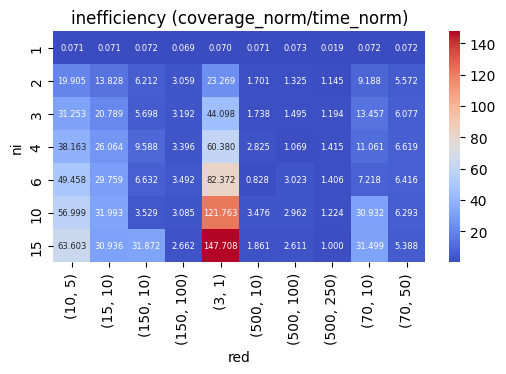

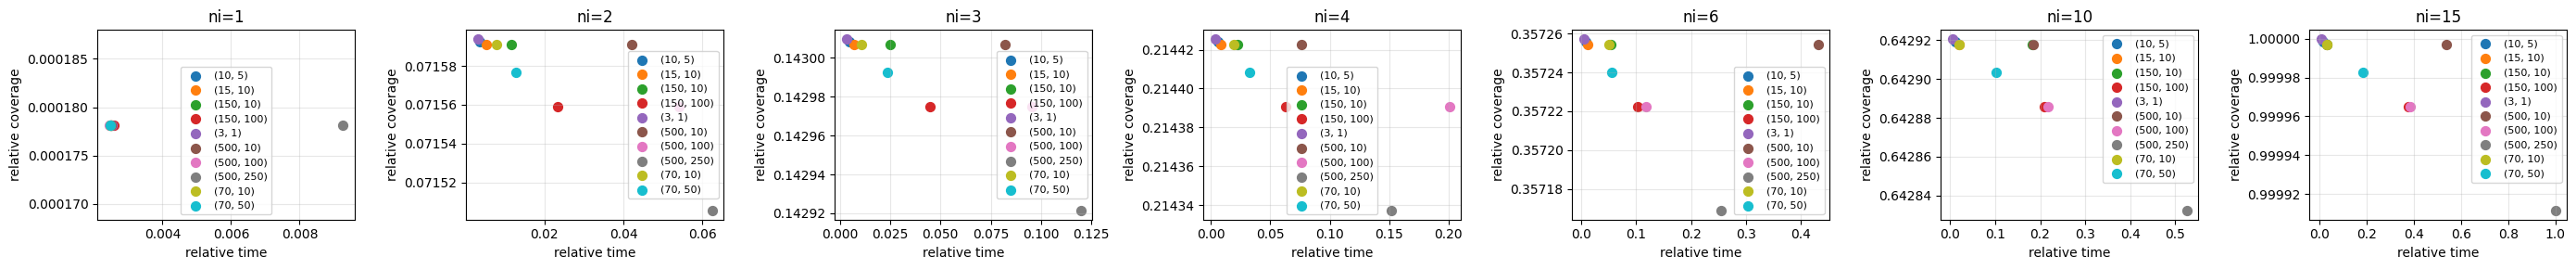

In [58]:
plot_temp(df)

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

def plot_temp2(df):
    # --- Heatmap summary ---
    df['efficiency'] = df['coverage_norm'] / df['time_norm']
    pivot_eff = df.pivot_table(
        index='num_intervals',
        columns='reduce_triggerSz_sizeLim',
        values='efficiency',
        aggfunc='mean'
    )
    
    plt.figure(figsize=(6,3))
    sns.heatmap(pivot_eff, annot=True, fmt=".2f", cmap="coolwarm", annot_kws={"size": 6})
    plt.title("Efficiency (coverage_norm/time_norm)")
    plt.xlabel("red")
    plt.ylabel("ni")
    plt.show()
    
    # --- Normalized scatter plots in 2 rows ---
    ni_values = sorted(df['num_intervals'].unique())
    red_configs = sorted(df['reduce_triggerSz_sizeLim'].unique())
    
    fig, axes = plt.subplots(2, len(ni_values), figsize=(4*len(ni_values), 6))  # 2 rows
    # axes is a 2D array: axes[row, col]
    
    for i, ni in enumerate(ni_values):
        for row in range(2):
            ax = axes[row, i]
            
            ni_df = df[df['num_intervals'] == ni]
            for r in red_configs:
                sub = ni_df[ni_df['reduce_triggerSz_sizeLim'] == r]
                if row == 0:
                    ax.scatter(sub['time_norm'], sub['coverage_norm'], label=str(r), s=50)
                    ax.set_xlabel('relative time')
                    ax.set_ylabel('relative coverage')
                    ax.set_title(f'Normalized scatter, ni={ni}')
                else:
                    ax.scatter(sub['sumtest_time_mean'], sub['result_coverage_mean'], label=str(r), s=50)
                    ax.set_xlabel('time (raw)')
                    ax.set_ylabel('coverage (raw)')
                    ax.set_title(f'Raw scatter, ni={ni}')
                
                # remove scientific notation
                ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=False, useOffset=False))
                ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=False, useOffset=False))
            
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=8)
    
    plt.tight_layout()
    plt.show()

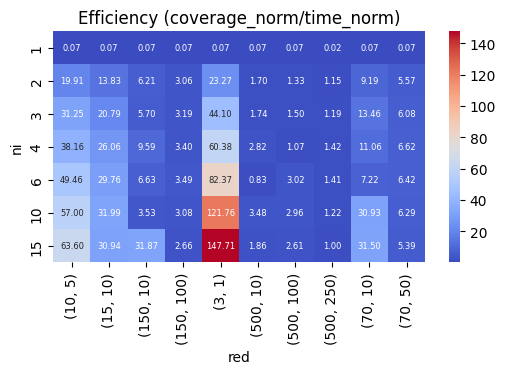

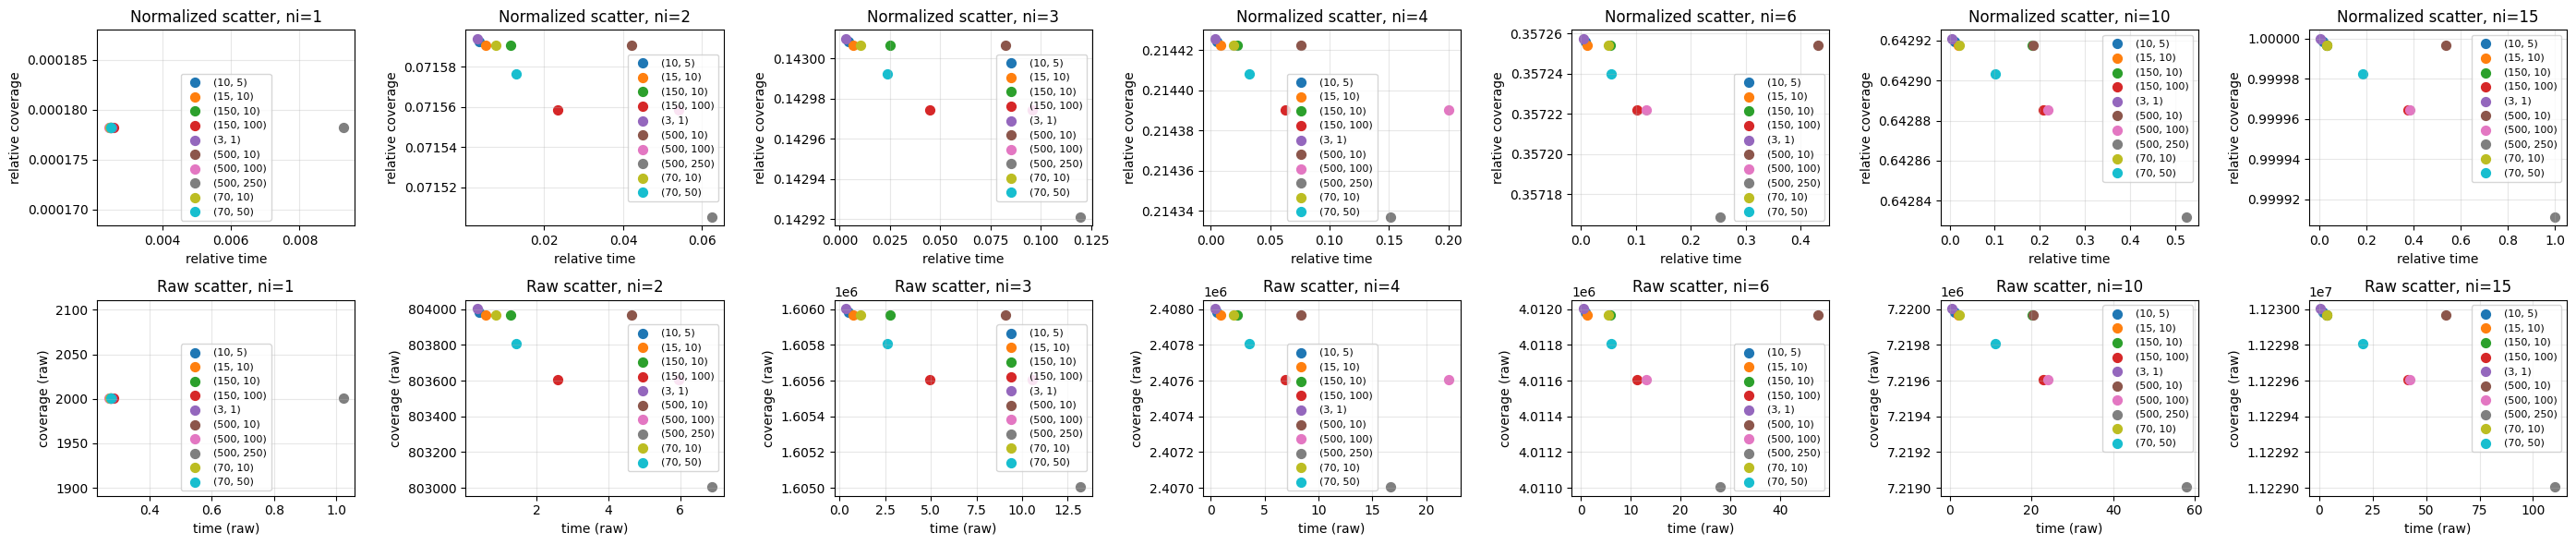

In [56]:
plot_temp2(df)

In [74]:
import numpy as np
import pandas as pd

def pareto_front_minimize(df, x_col='time_norm', y_col='coverage_norm'):
    """
    Returns a boolean mask indicating which rows are on the Pareto front
    when both x and y are to be minimized.
    """
    # Sort by time ascending (smaller is better)
    df_sorted = df.sort_values(x_col, ascending=True)
    pareto_mask = np.zeros(len(df_sorted), dtype=bool)

    best_y = np.inf  # smallest coverage seen so far
    for idx in df_sorted.index:
        y_val = df_sorted.loc[idx, y_col]
        if y_val <= best_y:
            pareto_mask[idx] = True
            best_y = y_val  # update smallest coverage

    return pareto_mask

def plot_efficiency_vs_ni(df:pd.DataFrame, filename="efficiency_vs_ni.pdf"):
    # filename = f"{self.resultFilepath}/{filename}"
    with PdfPages(filename) as pdf:
        # heatmap reduce_triggers(x) vs NI(y) 
        pivot_eff = df.pivot_table(
            index='num_intervals',
            columns='reduce_triggerSz_sizeLim',
            values='efficiency',
            aggfunc='mean'
        )
        plt.figure(figsize=(6,3))
        sns.heatmap(pivot_eff, annot=True, fmt=".2f", cmap="coolwarm", annot_kws={"size": 6})
        plt.title("Efficiency (coverage_norm/time_norm)")
        plt.xlabel("red")
        plt.ylabel("ni")
        pdf.savefig(bbox_inches='tight')
        plt.close()
        
        ni_values = sorted(df['num_intervals'].unique())
        red_configs = sorted(df['reduce_triggerSz_sizeLim'].unique())
        pareto_res = pareto_front_minimize(df)
        pareto_points = df[pareto_res]
        
        fig, axes = plt.subplots(1, len(ni_values), figsize=(4*len(ni_values), 3))
        axes = axes.flatten() if len(ni_values) > 1 else [axes]
        # fig.text(0.5, 0.05, self.param_str, ha='center', va='center', fontsize=7, color='black', wrap=True)

        handles, labels = None, None
        for i, ni in enumerate(ni_values):
            ax = axes[i]
            ni_df = df[df['num_intervals'] == ni]
            
            # plot all points
            for r in red_configs:
                sub = ni_df[ni_df['reduce_triggerSz_sizeLim'] == r]
                ax.scatter(sub['time_norm'], sub['coverage_norm'], label=str(r), s=50)
            # ax.scatter(pareto_points['time_norm'], pareto_points['coverage_norm'], color='black', s=80, marker='*', label='Pareto front')
            
            # compute and highlight Pareto front
            mask = pareto_front(ni_df)
            pareto_points = df[mask]
            ax.scatter(pareto_points['time_norm'], pareto_points['coverage_norm'], 
                       color='black', s=80, marker='*', label='Pareto front')
            
            if handles is None:
                handles, labels = ax.get_legend_handles_labels()

            # no scientific notation
            ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=False, useOffset=False))
            ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=False, useOffset=False))
            
            ax.set_title(f'ni={ni}')
            ax.set_xlabel('relative time')
            ax.set_ylabel('relative coverage')
            ax.grid(True, alpha=0.3)
        
        # tidy layout
        plt.tight_layout(rect=[0, 0.08, 0.85, 1])
        pdf.savefig(bbox_inches='tight')
        plt.close()

        # legend page
        fig = plt.figure(figsize=(6,2))
        fig.legend(handles, labels, title='(trigger, size_limit)', loc='center', fontsize=8)
        pdf.savefig(bbox_inches='tight')
        plt.close()

KeyError: "None of [Index([1, 6, 4, 5, 8, 2, 7, 9, 3, 0], dtype='int64')] are in the [columns]"

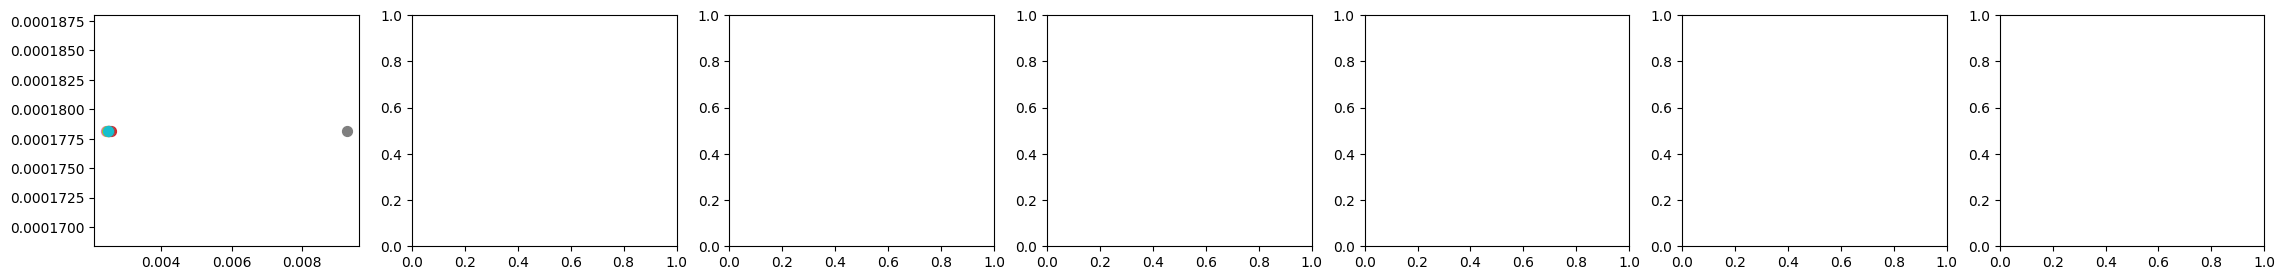

In [75]:
plot_efficiency_vs_ni(df)

In [98]:
class a:
    def plot_efficiency_vs_ni(self, df: pd.DataFrame, filename="efficiency_vs_ni.pdf"):
        from matplotlib.backends.backend_pdf import PdfPages
        from matplotlib.ticker import ScalarFormatter
        import seaborn as sns
        import matplotlib.pyplot as plt
        import numpy as np
    
        # filename = f"{self.resultFilepath}/{filename}"
        with PdfPages(filename) as pdf:
            # Heatmap of efficiency
            pivot_eff = df.pivot_table(
                index='num_intervals',
                columns='reduce_triggerSz_sizeLim',
                values='efficiency',
                aggfunc='mean'
            )
            plt.figure(figsize=(6,3))
            sns.heatmap(pivot_eff, annot=True, fmt=".2f", cmap="coolwarm", annot_kws={"size": 6})
            plt.title("Efficiency (coverage_norm/time_norm)")
            plt.xlabel("red")
            plt.ylabel("ni")
            pdf.savefig(bbox_inches='tight')
            plt.close()
    
            ni_values = sorted(df['num_intervals'].unique())
            red_configs = sorted(df['reduce_triggerSz_sizeLim'].unique())
            fig, axes = plt.subplots(1, len(ni_values), figsize=(4*len(ni_values), 3))
            axes = axes.flatten() if len(ni_values) > 1 else [axes]
            # fig.text(0.5, 0.05, self.param_str, ha='center', va='center', fontsize=7, color='black', wrap=True)
    
            handles, labels = None, None
            for i, ni in enumerate(ni_values):
                ax = axes[i]
                ni_df = df[df['num_intervals'] == ni]
            
                agg_df = ni_df.groupby('reduce_triggerSz_sizeLim').agg({
                    'time_norm': 'mean',
                    'coverage_norm': 'mean'
                }).reset_index()
                
                # skip if only one unique value (avoid divide by zero)
                time_range = agg_df['time_norm'].max() - agg_df['time_norm'].min()
                coverage_range = agg_df['coverage_norm'].max() - agg_df['coverage_norm'].min()
                
                if time_range == 0:
                    agg_df['time_scaled'] = 0
                else:
                    agg_df['time_scaled'] = (agg_df['time_norm'] - agg_df['time_norm'].min()) / time_range
                
                if coverage_range == 0:
                    agg_df['coverage_scaled'] = 0
                else:
                    agg_df['coverage_scaled'] = (agg_df['coverage_norm'] - agg_df['coverage_norm'].min()) / coverage_range
                
                agg_df['dist'] = np.sqrt(agg_df['time_scaled']**2 + agg_df['coverage_scaled']**2)
                
                # drop NaNs just in case
                agg_df = agg_df.dropna(subset=['dist'])
                
                best_point = agg_df.loc[agg_df['dist'].idxmin()]
                print(best_point)
            
                # Step 3: plot all points
                for r in red_configs:
                    sub = ni_df[ni_df['reduce_triggerSz_sizeLim'] == r]
                    ax.scatter(sub['time_norm'], sub['coverage_norm'], label=str(r), s=50)
                
                # Step 4: plot optimal point as a star
                ax.scatter(
                    best_point['time_norm'], 
                    best_point['coverage_norm'], 
                    color='black', s=100, marker='*', label='Optimal'
                )
            
                if handles is None:
                    handles, labels = ax.get_legend_handles_labels()
            
                ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=False, useOffset=False))
                ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=False, useOffset=False))
                ax.set_title(f'ni={ni}')
                ax.set_xlabel('relative time')
                ax.set_ylabel('relative coverage')
                ax.grid(True, alpha=0.3)
    
            plt.tight_layout(rect=[0, 0.08, 0.85, 1])
            pdf.savefig(bbox_inches='tight')
            plt.close()
    
            # Legend only page
            fig = plt.figure(figsize=(6,2))
            fig.legend(handles, labels, title='(trigger, size_limit)', loc='center', fontsize=8)
            pdf.savefig(bbox_inches='tight')
            plt.close()


In [99]:
c = a()
c.plot_efficiency_vs_ni(df)

reduce_triggerSz_sizeLim    (500, 100)
time_norm                     0.002445
coverage_norm                 0.000178
time_scaled                        0.0
coverage_scaled                      0
dist                               0.0
Name: 6, dtype: object
reduce_triggerSz_sizeLim    (150, 100)
time_norm                     0.023396
coverage_norm                 0.071559
time_scaled                   0.342259
coverage_scaled                0.60241
dist                          0.692848
Name: 3, dtype: object
reduce_triggerSz_sizeLim    (150, 100)
time_norm                     0.044786
coverage_norm                 0.142975
time_scaled                   0.356707
coverage_scaled                0.60241
dist                          0.700098
Name: 3, dtype: object
reduce_triggerSz_sizeLim    (150, 100)
time_norm                     0.063138
coverage_norm                  0.21439
time_scaled                   0.302554
coverage_scaled                0.60241
dist                          0.67

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

def plot_time_vs_coverage_all_ni(df):
    plt.figure(figsize=(8,5))
    
    # Scatter with 'time_norm' vs 'coverage_norm'
    # color by num_intervals, marker by reduce_triggerSz_sizeLim
    sns.scatterplot(
        data=df,
        x='time_norm',
        y='coverage_norm',
        hue='num_intervals',              # color = ni
        style='reduce_triggerSz_sizeLim', # different shapes for red params
        s=60
    )
    
    plt.xlabel("Relative Time")
    plt.ylabel("Relative Coverage")
    plt.title("Time vs Coverage (all num_intervals)")
    plt.grid(alpha=0.3)
    
    # no scientific notation
    plt.gca().xaxis.set_major_formatter(ScalarFormatter(useMathText=False, useOffset=False))
    plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=False, useOffset=False))
    
    plt.legend(title='ni / red', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

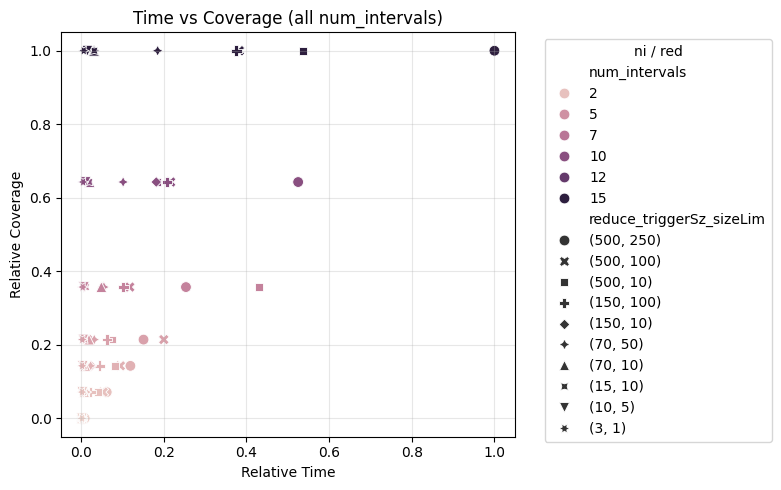

In [101]:
plot_time_vs_coverage_all_ni(df)

In [112]:
def plot_time_vs_coverage_all_ni(df, filename="time_vs_coverage.pdf"):
    from matplotlib.backends.backend_pdf import PdfPages
    from matplotlib.ticker import ScalarFormatter
    import seaborn as sns
    import matplotlib.pyplot as plt

    agg_df = df.groupby(['num_intervals', 'reduce_triggerSz_sizeLim']).agg({
        'time_norm': 'mean',
        'coverage_norm': 'mean'
    }).reset_index()

    with PdfPages(filename) as pdf:
        fig, ax = plt.subplots(figsize=(8, 5))

        sns.scatterplot(
            data=agg_df,
            x='time_norm',
            y='coverage_norm',
            hue='reduce_triggerSz_sizeLim',
            style='num_intervals',
            s=60,
            ax=ax
        )

        ax.set_xlabel("Relative Time")
        ax.set_ylabel("Relative Coverage")
        ax.set_title("Time vs Coverage (all num_intervals)")
        ax.grid(alpha=0.3)
        ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=False, useOffset=False))
        ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=False, useOffset=False))
        ax.legend(title='ni / red', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)

        plt.tight_layout()
        pdf.savefig(bbox_inches='tight')
        plt.close()

        fig, ax = plt.subplots(figsize=(8, 5))
        sns.scatterplot(
            data=agg_df,
            x='time_norm',
            y='coverage_norm',
            hue='reduce_triggerSz_sizeLim',
            # style='num_intervals',
            s=60,
            ax=ax
        )

        ax.set_xlabel("Relative Time")
        ax.set_ylabel("Relative Coverage")
        ax.set_title("Time vs Coverage (all num_intervals)")
        ax.grid(alpha=0.3)
        ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=False, useOffset=False))
        ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=False, useOffset=False))
        ax.legend(title='ni / red', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)

        plt.tight_layout()
        pdf.savefig(bbox_inches='tight')
        plt.close()

In [113]:
plot_time_vs_coverage_all_ni(df)